In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotnine as p9

from sklearn import preprocessing
from brainsmash.mapgen.stats import spearmanr as bs_spearmanr
from statsmodels.stats.multitest import fdrcorrection

import pickle

In [15]:
# load cell type marker
celltype_marker = pd.read_csv("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/rawdata/celltypes_PSP.csv")

# prepare celltype marker list
total_genelist = pd.read_csv("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/01.gene_selection/gene_score_pr_activate_kwx.csv", header=None)[0].unique()
celltype_marker_mmu = celltype_marker.loc[celltype_marker['gene'].isin(total_genelist), :]
celltype_class = celltype_marker_mmu['class'].unique()
celltype_marker_use = {celltype : set(celltype_marker_mmu.loc[celltype_marker_mmu['class']==celltype, "gene"].unique()) for celltype in celltype_class }
celltype_class

array(['Astro', 'Endo', 'Micro', 'Neuro-Ex', 'Neuro-In', 'Oligo', 'OPC'],
      dtype=object)

In [16]:
# clac posi/nega gene
gene_score = pd.read_csv("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/05.new_gene_score_list/gene_score_activate_increase_coupling_kwx.csv", header=None, index_col=0)
gene_score.shape

(636, 1)

# Validation

In [17]:
# validation
threshold_use = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
n_perm = 10000
ctd_validate_res = []
for threshold in threshold_use:
    n = int(gene_score.shape[0] * threshold)

    # extract gene symbol
    gene_symbol = pd.Series(gene_score.index[:n])
    print(n, gene_symbol.shape)

    # clac ratio
    ctd = np.array([ gene_symbol.isin(celltype_marker_use[celltype]).sum()/len(gene_symbol) for celltype in celltype_class ])
    
    # permutation
    ctd_null = np.zeros(shape=(n_perm, len(celltype_class)))
    for i, celltype in enumerate(celltype_class):
        for k in range(n_perm):
            perm_gene_symbol = np.random.choice(total_genelist, size=len(gene_symbol), replace=False )
            ctd_null[k, i] = pd.Series(perm_gene_symbol).isin(celltype_marker_use[celltype]).sum() / len(gene_symbol)
            
    # calc pval
    tmp_a = np.abs(ctd_null - ctd_null.mean(axis=0))
    tmp_b = np.abs(ctd - ctd_null.mean(axis=0))
    ctd_pval = ((tmp_a>=tmp_b).sum(axis=0)+1)/(n_perm+1)
    ctd_fdr = fdrcorrection(ctd_pval, alpha=0.05, method="indep", is_sorted=False)[1]


    ctd_validate_res.append([ctd, ctd_null, ctd_pval, ctd_fdr])

    #break

31 (31,)
63 (63,)
127 (127,)
190 (190,)
254 (254,)
318 (318,)
381 (381,)
445 (445,)
508 (508,)
572 (572,)
636 (636,)


In [18]:
pickle.dump(ctd_validate_res, open("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/06.celltype/ctd_activate_increase_res_kwx.pkl", "wb"))
ctd_validate_res = pickle.load(open("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/06.celltype/ctd_activate_increase_res_kwx.pkl", "rb"))

In [19]:
threshold_use = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
validate_dat = pd.DataFrame([ ctd_validate_res[i][0] - ctd_validate_res[i][1].mean(axis=0) for i in range(len(threshold_use)) ], index=threshold_use, columns=celltype_class).melt(value_name="Ratio", var_name="Class")
validate_dat["FDR"] =  pd.DataFrame([ ctd_validate_res[i][3] for i in range(len(threshold_use)) ], index=threshold_use, columns=celltype_class).melt(value_name="FDR", var_name="Class")["FDR"]
validate_dat["Threshold"] = threshold_use * 7
#posi_dat["Category"] = "Positive"

validate_dat_point = validate_dat.loc[validate_dat["FDR"]<0.05, :]

/opt/anaconda3/lib/python3.13/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


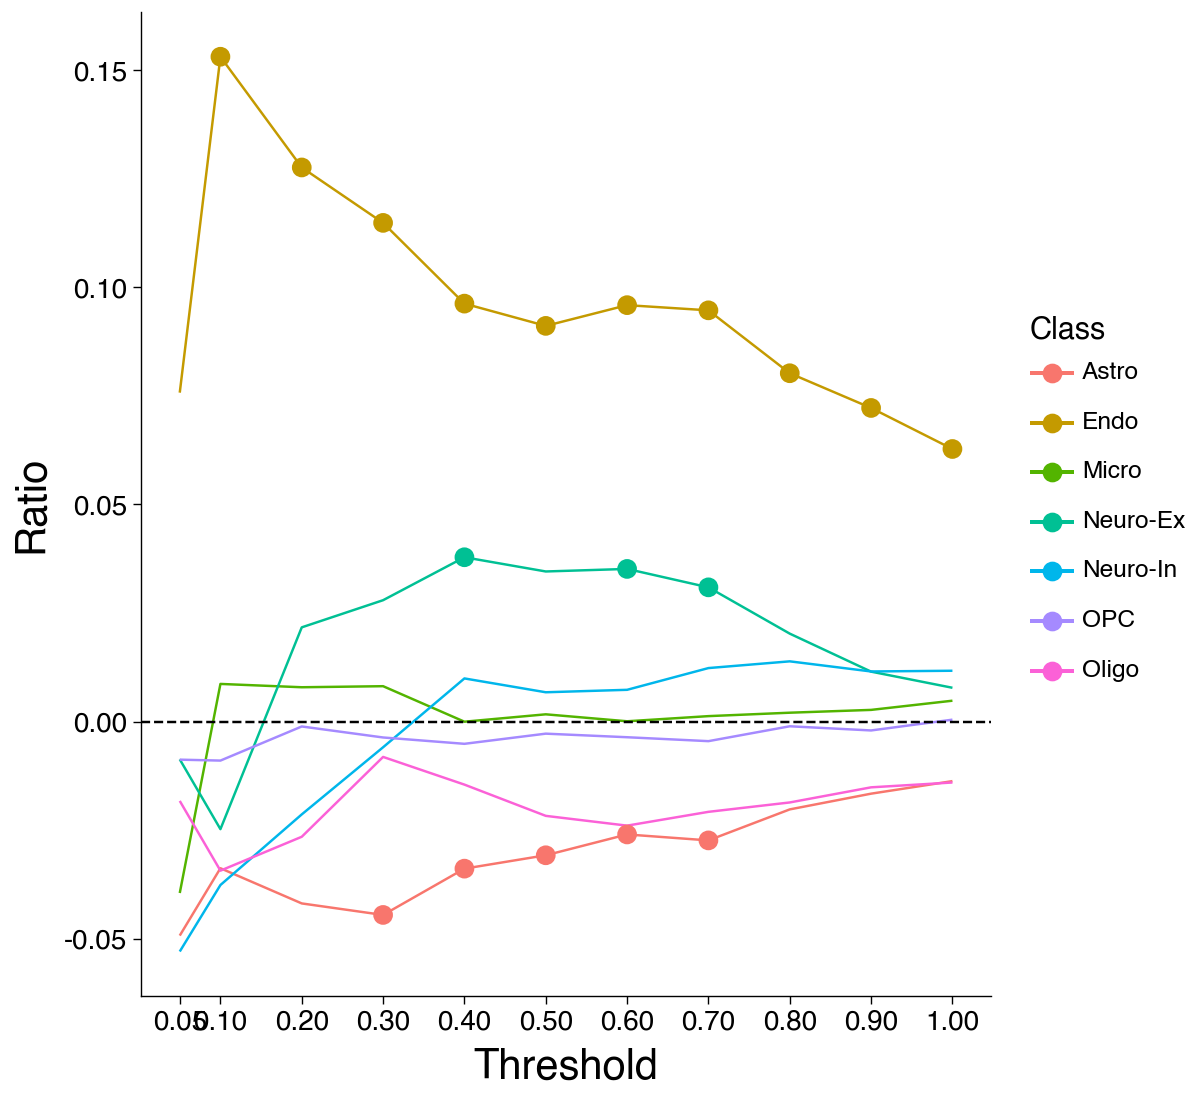

In [20]:
validat_plot = (
    p9.ggplot(p9.aes(x="Threshold", y="Ratio", color="Class", group="Class"), validate_dat)
    + p9.geom_line()
    + p9.geom_point(p9.aes(x="Threshold",y="Ratio", color="Class"), validate_dat_point, size=3)
    + p9.geom_hline(yintercept=0, linetype="dashed")
    + p9.scale_x_continuous(breaks=threshold_use)
    + p9.theme_classic()
    + p9.theme(figure_size=(6, 5.5),
                axis_line = p9.element_line(color="black", linewidth=0.5),
                axis_ticks = p9.element_line(color="black", linewidth=0.5),
                axis_ticks_minor = p9.element_blank(),
                axis_text = p9.element_text(color="black", size=10),
                #axis.text.y = element_text(angle=30),
                axis_title = p9.element_text(color="black", size=15),
                panel_grid = p9.element_blank(),
                panel_background = p9.element_blank(),
                panel_border = p9.element_blank(),
                panel_ontop = p9.element_blank(),

               subplots_adjust={"wspace":0.15})
    #+ p9.facet_wrap("~Category", ncol=2, scales="free_y")
)
p9.ggsave(validat_plot, "/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/06.celltype/ctd_activate_increase_validate_kwx.pdf", verbose=False)
validat_plot

# percentile

In [21]:
ctd_validate_res = pickle.load(open("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/06.celltype/ctd_activate_increase_res_kwx.pkl", "rb"))
ctd_null = ctd_validate_res[1][1]

In [22]:
threshold_use = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1]
n_perm = ctd_null.shape[0]

percentile_ratio = []
percentile_pval = []
for t1, t2 in zip(threshold_use[:-1], threshold_use[1:]):
    n1 = int(gene_score.shape[0] * t1)
    n2 = int(gene_score.shape[0] * t2)

    gene_symbol = pd.Series(gene_score.index[n1:n2])
    print(n1, n2, gene_symbol.shape)

    ctd = np.array([ gene_symbol.isin(celltype_marker_use[celltype]).sum()/len(gene_symbol) for celltype in celltype_class ])
    percentile_ratio.append(ctd)

    # calc pval
    tmp_a = ctd_null - ctd_null.mean(axis=0)
    tmp_b = ctd - ctd_null.mean(axis=0)
    ctd_pval = ((tmp_a>=tmp_b).sum(axis=0)+1)/(n_perm+1)
    percentile_pval.append(ctd_pval)

0 63 (63,)
63 127 (64,)
127 190 (63,)
190 254 (64,)
254 318 (64,)
318 381 (63,)
381 445 (64,)
445 508 (63,)
508 572 (64,)
572 636 (64,)


In [23]:
idx_name = ["0-10", "10-20", "20-30", "30-40", "40-50", "50-60", "60-70", "70-80", "80-90", "90-100"]
plot_dat1 = pd.DataFrame(percentile_ratio, columns=celltype_class, index=idx_name).melt(value_name="Ratio", var_name="Celltype", ignore_index=False).reset_index()
plot_dat2 = pd.DataFrame(percentile_pval, columns=celltype_class, index=idx_name).melt(value_name="Pval", var_name="Celltype", ignore_index=False).reset_index()
plot_dat = pd.merge(left=plot_dat1, right=plot_dat2, on=["index", "Celltype"])
plot_dat.columns = ["Percentile", "Celltype", "Ratio", "Pval"]
plot_dat["Percentile"] = pd.Categorical(plot_dat["Percentile"], categories=idx_name)
plot_dat["FDR"] = fdrcorrection(plot_dat["Pval"], alpha=0.05, method="indep", is_sorted=False)[1]
sig_dat = plot_dat.loc[plot_dat["FDR"]<0.05, :]
sig_dat

,Percentile,Celltype,Ratio,Pval,FDR
10,0-10,Endo,0.206349,0.0001,0.006999
15,50-60,Endo,0.174603,0.0008,0.027997


/opt/anaconda3/lib/python3.13/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


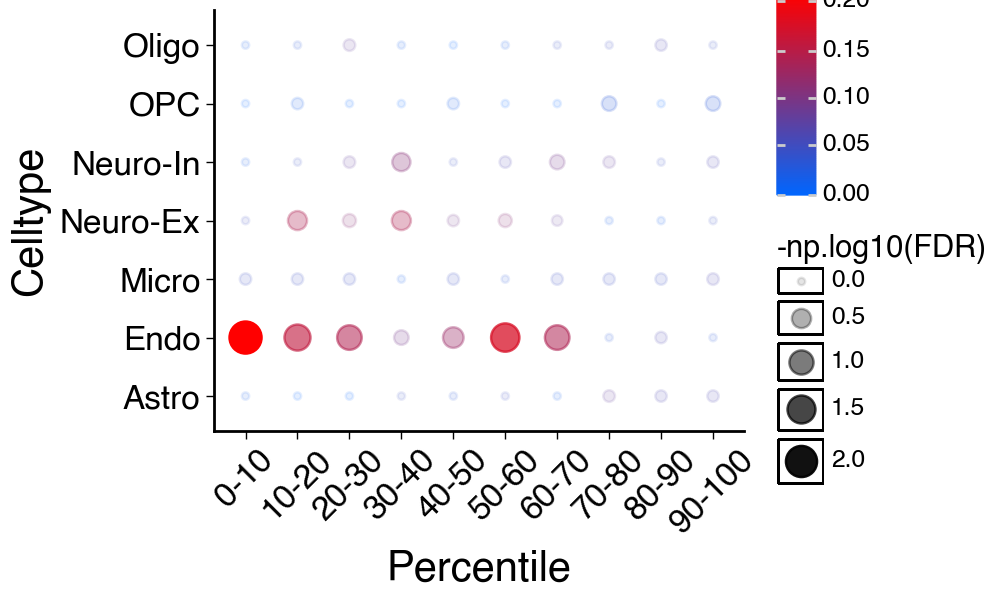

In [24]:
plot_scatter = (
    p9.ggplot()
    #+ p9.geom_line(data=plot_dat, mapping=p9.aes(x="Percentile", y="Ratio", color="Celltype", alpha="-np.log10(Pval)"))
    + p9.geom_point(data=plot_dat, mapping=p9.aes(x="Percentile", y="Celltype", size="-np.log10(FDR)", 
                                                  color="Ratio", alpha="-np.log10(FDR)") )
    + p9.scale_color_gradient(high="red", low="#0066FF")
    #+ p9.scale_color_gradient2(high="red", low="#0066FF", mid="black",)
    #+ p9.scale_size_continuous(breaks=[1.5, 2, 2.5, 3])
    #+ p9.scale_fill_gradient(low="#0066FF", high="red", limits=[-2, 1])
    #+ p9.ylim(0, 0.12)
    + p9.theme_classic()
    + p9.theme(
        figure_size=(5, 3),
        panel_background=p9.element_rect(color="black", size=0.5),
        panel_grid=p9.element_blank(),
        axis_ticks=p9.element_line(color="black", size=0.5),
        axis_ticks_length_minor=0,
        axis_ticks_minor=p9.element_blank(),
        axis_text=p9.element_text(color="black", size=12),
        axis_text_x=p9.element_text(rotation=45, hjust=-1),
        axis_title = p9.element_text(color="black", size=15),
        
        legend_background=p9.element_blank(),
        #legend_title=p9.element_blank(), 
        legend_key_size=10,
        #legend_position=(0.3, 0.75),
        legend_direction="vertical",
        strip_background=p9.element_blank(),
        #strip_text=p9.element_blank(),
        
        subplots_adjust={"hspace":0.1},
    )
    #+ p9.facet_wrap("~Celltype", ncol=1, scales="free_y")

)
p9.ggsave(plot_scatter, "/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/06.celltype/ctd_activate_increase_percentile_scatter_kwx.pdf", verbose=False)
plot_scatter

In [25]:
# dat for boxplot
ctd_validate_res = pickle.load(open("/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/06.celltype/ctd_activate_increase_res_kwx.pkl", "rb"))
ctd_null = ctd_validate_res[1][1]
ctd_null = pd.DataFrame(ctd_null, columns=celltype_class).melt(value_name="Ratio", var_name="Celltype")
boxplot_dat = ctd_null

ctd = plot_dat.loc[plot_dat["Percentile"] == "50-60", :].copy()
scatter_dat = ctd
scatter_dat["Ratio"] = scatter_dat["Ratio"].astype(float)
scatter_dat["y"] = 0.22
scatter_dat["Label"] = [ f"* {fdr:.4f}" if fdr < 0.05 else f"{fdr:.4f}" for fdr in scatter_dat["FDR"] ]

/opt/anaconda3/lib/python3.13/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


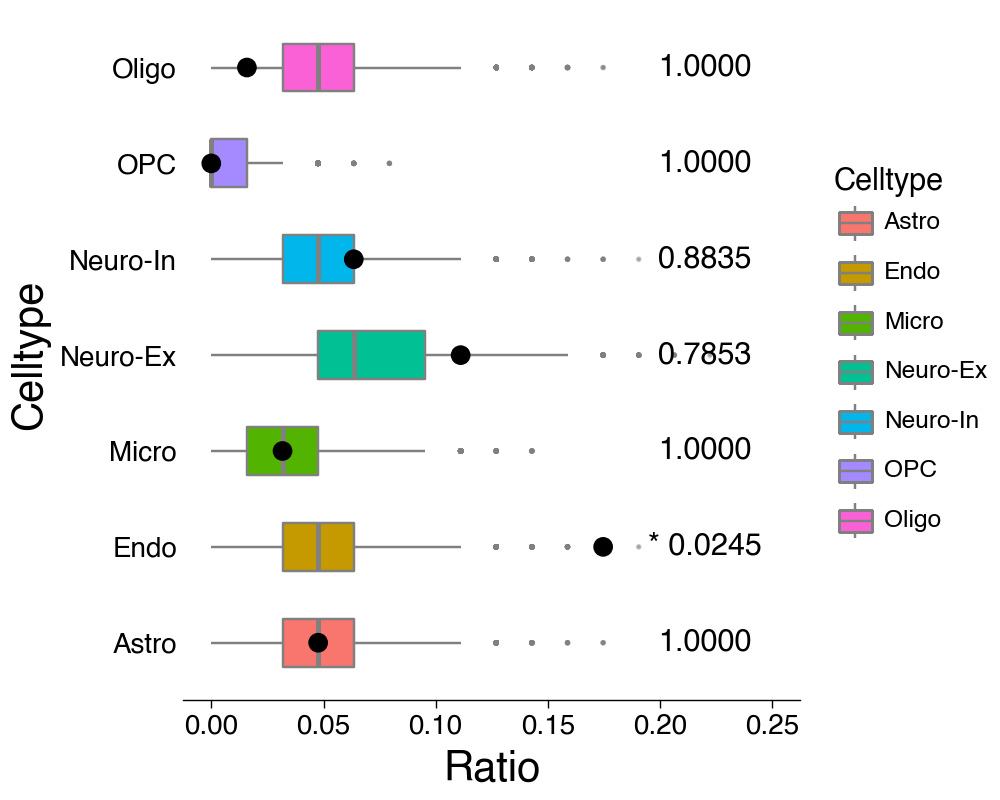

In [34]:
ctd_plot = (
    p9.ggplot(p9.aes(x="Celltype", y="Ratio"), boxplot_dat)
    + p9.geom_boxplot(p9.aes(fill="Celltype"), color="grey", width=0.5, outlier_size=0.1, outlier_alpha=0.5)
    + p9.geom_point(p9.aes(x="Celltype", y="Ratio"), scatter_dat, color="black", size=3)
    + p9.geom_text(p9.aes(x="Celltype", y="y", label="Label"), scatter_dat,color="black")
    + p9.ylim(0, 0.25)
    + p9.theme_classic()
    + p9.theme(figure_size=(5, 4),
               axis_text = p9.element_text(color="black", size=10),
               axis_line = p9.element_line(color="black", linewidth=0.5),
               axis_line_y = p9.element_blank(),
               axis_ticks = p9.element_line(color="black", linewidth=0.5),
               axis_ticks_minor = p9.element_blank(),
               axis_ticks_major_y = p9.element_blank(),

                axis_title = p9.element_text(color="black", size=15),
                panel_grid = p9.element_blank(),
                panel_background = p9.element_blank(),
                panel_border = p9.element_blank(),
                panel_ontop = p9.element_blank(),
               
               subplots_adjust={"wspace":0.18})
    + p9.coord_flip()
    #+ p9.facet_wrap("~Category", ncol=2, scales="free")
)
p9.ggsave(ctd_plot, "/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/res/06.celltype/ctd_activate_increase_use_kwx.pdf", verbose=False)
ctd_plot

/opt/anaconda3/lib/python3.13/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.
/opt/anaconda3/lib/python3.13/site-packages/plotnine/themes/themeable.py:2486: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This parameter will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


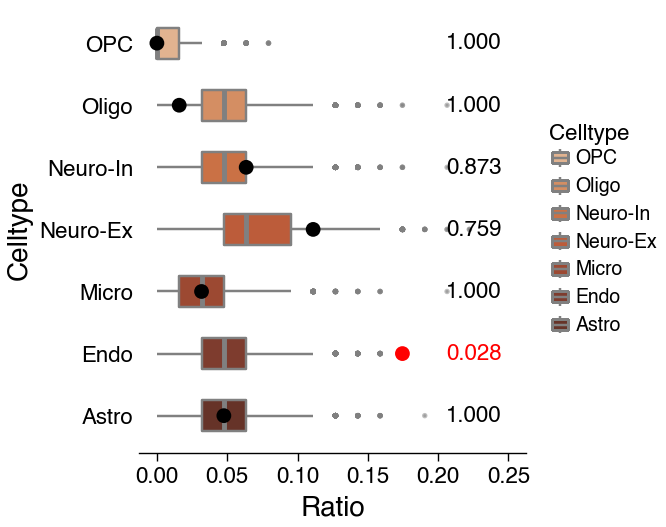

In [27]:
import plotnine as p9


from matplotlib import rcParams

scatter_dat["FDR"] = pd.to_numeric(scatter_dat["FDR"], errors="coerce")

scatter_dat["Label"] = scatter_dat["FDR"].apply(
    lambda x: f"{x:.3f}" if pd.notna(x) else ""
)

rcParams["font.family"] = "Arial"

palette_tropical = [
    "#EDD2BB", "#E1B390", "#D48E63", "#CA7145",
    "#BC5C3A", "#9C4932", "#7E3C2E", "#663328"
]

palette_tropical = palette_tropical[::-1]

celltype_order = list(celltype_class)

celltype_colors = {ct: palette_tropical[i % len(palette_tropical)] 

                   for i, ct in enumerate(celltype_order)}



boxplot_dat["Celltype"] = pd.Categorical(

    boxplot_dat["Celltype"],

    categories=celltype_order,

    ordered=True

)



scatter_dat["Celltype"] = pd.Categorical(

    scatter_dat["Celltype"],

    categories=celltype_order,

    ordered=True

)



# ✅ 右侧数值列对齐：统一放到同一个 x 位置（这里是 y=0.245），并用右对齐

scatter_dat["y"] = 0.245



# =========================

# ✅ 显著性自动标红：用 FDR（与你的 Label 一致）

# =========================

scatter_dat["FDR"] = pd.to_numeric(scatter_dat["FDR"], errors="coerce")

scatter_dat["sig_color"] = scatter_dat["FDR"].apply(

    lambda x: "red" if (pd.notna(x) and x < 0.05) else "black"

)
# =========================
# 画图调整
# =========================
ctd_plot = (
    p9.ggplot(p9.aes(x="Celltype", y="Ratio"), boxplot_dat)
    + p9.geom_boxplot(
        p9.aes(fill="Celltype"),
        color="grey",
        width=0.5,
        outlier_size=0.1,
        outlier_alpha=0.5
    )
    + p9.scale_fill_manual(values=celltype_colors)

    + p9.geom_point(
        p9.aes(x="Celltype", y="Ratio", color="sig_color"),
        scatter_dat,
        size=2  # 画布变小了，点的大小也适当微调
    )

    + p9.geom_text(
        p9.aes(x="Celltype", y="y", label="Label", color="sig_color"),
        scatter_dat,
        ha="right",
        size=8  # ✅ 每个 celltype 的数值设为 8pt
    )

    + p9.scale_color_identity()
    + p9.ylim(0, 0.25)
    + p9.theme_classic()
    + p9.theme(
        # ✅ 画布大小调整为 240pt * 190pt (单位 inch)
        figure_size=(240/72, 190/72),
        
        # ✅ 坐标轴标题 (Ratio 和 Celltype) 设为 10pt
        axis_title = p9.element_text(color="black", size=10),
        
        # ✅ 坐标轴刻度文字 (纵坐标和横坐标) 设为 8pt
        axis_text = p9.element_text(color="black", size=8),
        
        # ✅ 图例标题 (Celltype) 设为 8pt
        legend_title = p9.element_text(size=8),
        
        # ✅ 图例条目文字 (小字) 设为 7pt
        legend_text = p9.element_text(size=7),
        
        # 保持原有间距和边框逻辑
        axis_line = p9.element_line(color="black", linewidth=0.5),
        axis_line_y = p9.element_blank(),
        axis_ticks = p9.element_line(color="black", linewidth=0.5),
        axis_ticks_minor = p9.element_blank(),
        axis_ticks_major_y = p9.element_blank(),
        panel_grid = p9.element_blank(),
        panel_background = p9.element_blank(),
        legend_key_size = 8, # 适当缩小图例方块以配合小画布
        subplots_adjust={"wspace":0.18, "left": 0.3} # 增加左边距防止文字溢出
    )
    + p9.coord_flip()
    + p9.guides(fill=p9.guide_legend(reverse=True))
)

p9.ggsave(
    ctd_plot,
    "/Volumes/KWX/Grad/Programs/2025/202505/20250529/activity_gene_analysis/figures/results/2.3celltype_increase.png",
    dpi=1200,
    verbose=False
)

ctd_plot

In [22]:
print("null Ratio range:", boxplot_dat["Ratio"].min(), boxplot_dat["Ratio"].max())
print("real Ratio range:", scatter_dat["Ratio"].min(), scatter_dat["Ratio"].max())
print(scatter_dat[["Celltype","Percentile","Ratio","FDR"]])

null Ratio range: 0.0 0.18478260869565216
real Ratio range: nan nan
Empty DataFrame
Columns: [Celltype, Percentile, Ratio, FDR]
Index: []
